# <center> Проект: Прогнозирование рейтинга отеля на Booking
   

### <center> ВАРИАНТ 2: С новыми признаками

Признаки:  

hotel_address — адрес отеля;

additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.

review_date — дата, когда рецензент разместил соответствующий отзыв;

average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;

hotel_name — название отеля;

reviewer_nationality — страна рецензента;

negative_review — отрицательный отзыв, который рецензент дал отелю;

review_total_negative_word_counts — общее количество слов в отрицательном отзыв;

total_number_of_reviews — общее количество действительных отзывов об отеле;

positive_review — положительный отзыв, который рецензент дал отелю;

review_total_positive_word_counts — общее количество слов в положительном отзыве.

total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;

reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;

tags — теги, которые рецензент дал отелю;

days_since_review — количество дней между датой проверки и датой очистки;

lat — географическая широта отеля;

lng — географическая долгота отеля.

In [11]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
import numpy as np

In [12]:
# Чтение данных из файла
hotels = pd.read_csv('hotels.csv')
# Вывод информации о датасете
print("Информация о таблице:")
hotels.head()

Информация о таблице:


,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [13]:
# Вывод информации о столбцах
print(hotels.info())

<class 'pandas.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  str    
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  str    
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  str    
 5   reviewer_nationality                        386803 non-null  str    
 6   negative_review                             386803 non-null  str    
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  str    
 10  review_

In [14]:
# Для начала разделим признаки по типу, перечислим их:
# Непрерывные признаки
num_cols = ['additional_number_of_scoring', 'review_total_negative_word_counts', 'total_number_of_reviews', 
            'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score']

# Категориальные признаки
cat_cols = ['average_score', 'review_date', 'lat', 'lng']

#### <center> 1. Очищение DataFrame от дубликатов

In [15]:
# Проверяем долю дубликатов
display(hotels.duplicated().mean()*100)
# Очищаем датасет от дубликатов
hotels = hotels.drop_duplicates()
# Выводим краткую информацию о получившемся датасете
hotels.info()

np.float64(0.0793685674619897)

<class 'pandas.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386496 non-null  str    
 1   additional_number_of_scoring                386496 non-null  int64  
 2   review_date                                 386496 non-null  str    
 3   average_score                               386496 non-null  float64
 4   hotel_name                                  386496 non-null  str    
 5   reviewer_nationality                        386496 non-null  str    
 6   negative_review                             386496 non-null  str    
 7   review_total_negative_word_counts           386496 non-null  int64  
 8   total_number_of_reviews                     386496 non-null  int64  
 9   positive_review                             386496 non-null  str    
 10  review_total

#### <center> 2. Заполнение пропусков

In [16]:
# Заполняем пропуски
hotels = hotels.fillna(0)

#### <center> 3. Преобразование даты и создание квартала

In [17]:
# Преобразуем признак в формат даты
hotels['review_date'] = pd.to_datetime(hotels['review_date'], format='%m/%d/%Y')
# Создаем новый признак - квартал
hotels['review_quarter'] = hotels['review_date'].dt.quarter

# Проверяем распределение
print(hotels['review_quarter'].value_counts())

review_quarter
3    106724
2     99073
1     91092
4     89607
Name: count, dtype: int64


### Вывод:

Большинство отзывов (около 106 тыс.) приходится на 3-й квартал (летний период).

Это ожидаемо: летом люди чаще путешествуют и оставляют отзывы.

#### <center> 4. Кодирование страны рецензента (топ-11 стран)

In [18]:
# Определяем 11 самых популярных стран
top_countries = hotels['reviewer_nationality'].value_counts().head(11).index

# Создаём бинарный признак: 1 - если страна в топ-11, 0 - если нет
hotels['nationality_code'] = hotels['reviewer_nationality'].apply(lambda x: 1 if x in top_countries else 0)

# Проверяем распределение
print(hotels['nationality_code'].value_counts())

nationality_code
1    282651
0    103845
Name: count, dtype: int64


### Вывод:

Окло 282 тыс. рецензентов (около 73%) относятся к 11 самым популярным странам.

Остальные 104 тыс. (27%) - это редкие страны. Бинарное кодирование позволило сохранить эту информацию без создания десятков новых столбцов.

#### <center> 5. Извлечение длины отзывов и создание бинарных признаков наличия отзыва

In [19]:
# Количество слов в негативном отзыве (если отзыва нет - 0)
hotels['neg_len'] = hotels['negative_review'].apply(lambda x: len(x.split()) if x != 'No Negative' else 0)
# Количество слов в позитивном отзыве (если отзыва нет - 0)
hotels['pos_len'] = hotels['positive_review'].apply(lambda x: len(x.split()) if x != 'No Positive' else 0)

# Создаём бинарные признаки: есть отзыв (1) или нет (0)
hotels['has_neg'] = (hotels['neg_len'] > 0).astype(int)
hotels['has_pos'] = (hotels['pos_len'] > 0).astype(int)

# Удаляем исходные столбцы с количеством слов в отзывах
hotels = hotels.drop(['review_total_negative_word_counts', 'review_total_positive_word_counts'], axis=1)

# Выводим промежуточный результат
hotels.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,total_number_of_reviews,positive_review,total_number_of_reviews_reviewer_has_given,...,tags,days_since_review,lat,lng,review_quarter,nationality_code,neg_len,pos_len,has_neg,has_pos
0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,Leaving,1994,Staff were amazing,7,...,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671,1,1,1,3,1,1
1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,1361,location,14,...,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097,1,1,2,1,1,1


### Вывод:

В исходных данных были признаки review_total_positive_word_counts и review_total_negative_word_counts, но они считали пробелы как слова. 

Мы создали корректные признаки: количество слов в отзыве.

Также добавили бинарные признаки наличия отзыва - это может быть полезно, так как отсутствие отзыва тоже несёт информацию.

#### <center> 6. Извлечение страны отеля из адреса

In [20]:
def get_country_from_address(address):
    """ 
    Извлекает последнее слово (страну) из адреса

    Этапы обработки:
        1. Разбивает строку по пробелам.

    Args:
        address (str): Строка адреса
        
    Returns:
        list: Последний элемент

    """
    list_address = address.split()
    return list_address[-1]

# Создаём новый признак - страна отеля
hotels['hotel_country'] = hotels['hotel_address'].apply(get_country_from_address)

# Проверяем распределение
print(hotels['hotel_country'].value_counts())

hotel_country
Kingdom        196773
Spain           45132
France          44528
Netherlands     43004
Austria         29177
Italy           27882
Name: count, dtype: int64


### Вывод:

Больше всего отелей находится в Великобритании (196 тыс.), Испании (45 тыс.), Франции (44 тыс.) и Нидерландах (43 тыс.).

Это отражает географию датасета.

#### <center> 7. One-Hot кодирование страны отеля

In [21]:
# Создаем объект OneHotEncoder
encoder = ce.OneHotEncoder(cols=['hotel_country'], use_cat_names=True)
# Применяем трансформацию к столбцу
country_encoded = encoder.fit_transform(hotels['hotel_country'])

# Добавляем закодированные столбцы к основному DataFrame
hotels = pd.concat([hotels, country_encoded], axis=1)

# Удаляем исходный столбец со страной, а также lat и lng (они уже не нужны)
hotels = hotels.drop(['hotel_country', 'lat', 'lng'], axis=1)

### Вывод:

Применили One-Hot кодирование для страны отеля. Это позволит модели учитывать страну как категориальный признак.

lat и lng удалены, так как их информация уже учтена в стране.

#### <center> 8. Преобразование days_since_review

In [22]:
def extract_days(days_str):
    """ 
    Извлекает число дней из строки вида '203 days'
    
    Этапы обработки:
        1. Разбивает строку по пробелам.
    
    Args:
        days_str (str): Строка дней
            
    Returns:
        list: Первый элемент
    
    """
    lst = days_str.split()
    return lst[0]

# Применяем функцию извлечения, преобразуем в числовой тип
hotels['days_since_review'] = hotels['days_since_review'].apply(extract_days).astype(int)

#### <center> 9. Работа с тегами

In [23]:
# Создаем функцию преобразования строки в список
def split_str(tag):

    """ 
    Преобразует строковое представление списка тегов в список строк

    Этапы обработки:
        1. Удаляет квадратные скобки и кавычки по краям строки.
        2. Разбивает строку по запятым.
        3. Очищает каждый тег от лишних пробелов.
    
    Args:
        tag (str): Строка с тегами вида "['Leisure trip', 'Couple']"
    
    Returns:
        list: Список очищенных тегов

    """

    # Задаем пустую строку
    str_tags = ""
    # Задаем пустой список
    lst_tags = []

    # Проходим по каждому символу строки, удаляя лишние символы
    for row in tag:
        str_tags += row.strip('[]').replace("'", "")

    # Разделяем строку по запятым и добавляем теги в список
    for word in str_tags.split(','):
        lst_tags.append(word.strip())

    return lst_tags

# Преобразование колонки 'tags' из строки в список
hotels['tags'] = hotels['tags'].apply(split_str)

# Создаем отдельную строку для каждого тега
clean_tags = hotels.explode('tags')

# Выводим топ-15 тегов
print(clean_tags['tags'].value_counts().head(15))

tags
Leisure trip                      313353
Submitted from a mobile device    230608
Couple                            189046
Stayed 1 night                    145296
Stayed 2 nights                   100176
Solo traveler                      81166
Stayed 3 nights                    71940
Business trip                      61934
Group                              49057
Family with young children         45810
Stayed 4 nights                    35708
Double Room                        26386
Standard Double Room               24150
Superior Double Room               23518
Family with older children         19787
Name: count, dtype: int64


### Вывод:

Самые частые теги:
- 'Leisure trip' (313 тыс.),
- 'Couple' (189 тыс.),
- 'Stayed 1 night' (145 тыс.)

Эти теги отражают тип поездки, длительность пребывания.
Это ценные признаки для модели.

In [24]:
# Создаем признак - количество тегов у отеля
hotels['count_tags'] = hotels['tags'].apply(lambda x: len(x))

# Выберем топ популярных тегов по типу поездки
top_tags_type = [
    'Leisure trip',
    'Couple',
    'Solo traveler',
    'Business trip',
    'Group',
    'Family with young children'
]

# Выберем топ популярных тегов по длительности пребывания
top_tags_nights = [
    'Stayed 1 night',
    'Stayed 2 nights',
    'Stayed 3 nights',
    'Stayed 4 nights'
]

# Создаем бинарные признаки по типу поездки
for tag in top_tags_type:
    hotels[f'tag_{tag.replace(" ", "_")}'] = hotels['tags'].apply(lambda x: 1 if tag in x else 0)

# Создаем бинарные признаки по длительности пребывания
for tag in top_tags_nights:
    hotels[f'tag_{tag.replace(" ", "_")}'] = hotels['tags'].apply(lambda x: 1 if tag in x else 0)

### Вывод:

1. Создан признак count_tags - количество тегов у отеля. Отели с большим количеством тегов могут быть более детально описаны, что может влиять на рейтинг.

2. Созданы бинарные признаки для 6 самых частых типов поездок. Это позволит модели учитывать, с какой целью путешествует рецензент.

3. Созданы бинарные признаки для длительности пребывания (1-4 ночи). Это важно, так как краткосрочные и долгосрочные гости могут по-разному оценивать отель.

In [25]:
# Выведем сводную статистику для определенных признаков, в которых могут быть выбросы
columns = ['additional_number_of_scoring', 'total_number_of_reviews', 'neg_len', 'pos_len']
hotels[columns].describe()

,additional_number_of_scoring,total_number_of_reviews,neg_len,pos_len
count,386496.000000,386496.000000,386496.000000,386496.000000
mean,498.504375,2744.679231,17.352234,16.327631
std,500.365093,2316.934876,29.345290,21.482258
min,1.000000,43.000000,0.000000,0.000000
25%,169.000000,1161.000000,1.000000,4.000000
50%,342.000000,2134.000000,7.000000,10.000000
75%,660.000000,3633.000000,22.000000,21.000000
max,2682.000000,16670.000000,406.000000,393.000000


### Вывод:

В данных присутствуют выбросы: 
- max значительно превышает 75-й перцентиль total_number_of_reviews: 75% ≤ 3613, но max = 16670
- neg_len: 75% ≤ 22, но max = 406

Это указывает на наличие аномально высоких значений, которые могут искажать модель.

Выполним удаление выбросов методом Тьюки (IQR) и проведём логарифмирование для двух признаков  neg_len и total_number_of_reviews.

#### <center> 10. Логарифмирование и удаление выбросов

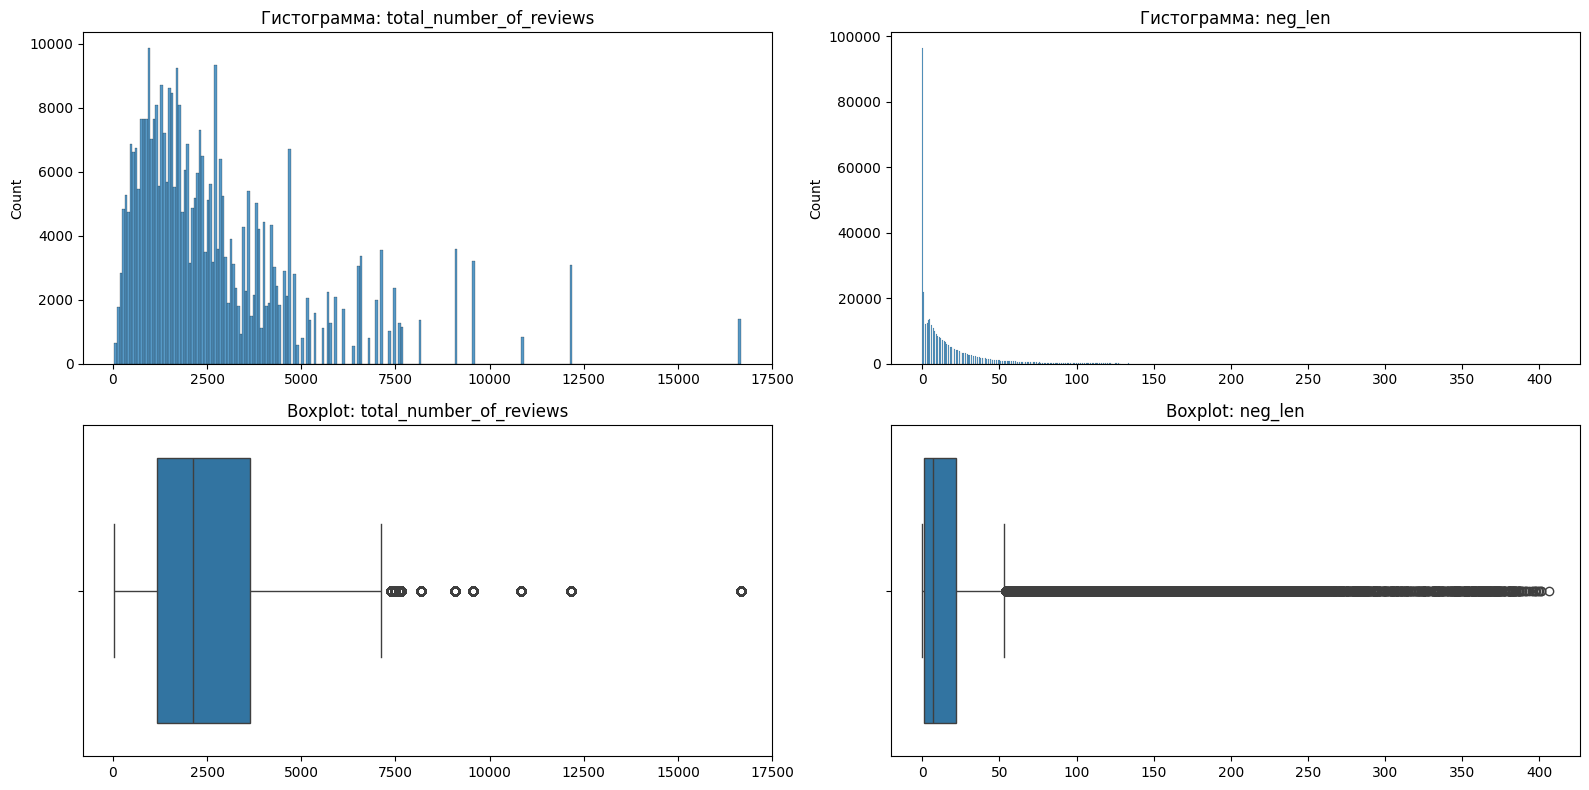

In [26]:
columns = ['total_number_of_reviews', 'neg_len']

# Выведем диаграммы для визуализации выбросов
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8))

for i, col in enumerate(columns):
    sns.histplot(data=hotels, x=col, ax=axes[0, i])
    axes[0, i].set_title(f'Гистограмма: {col}')
    axes[0, i].set_xlabel('')

    sns.boxplot(data=hotels, x=col, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_xlabel('')

plt.tight_layout()
plt.show()

### Вывод:

На гистограммах видно, что все признаки имеют скошенное вправо распределение (длинный правый хвост). Boxplot подтверждает наличие большого количества выбросов (точки за пределами усов) по каждому признаку.

In [27]:
def outliers_iqr(data, feature):
    """ 
    Удаляет выбросы по методу межквартильного размаха (Тьюки)

    Этапы обработки:
        1. Вычисляет первый (Q1) и третий (Q3) квартили признака.
        2. Рассчитывает межквартильный размах.
        3. Определяет нижнюю и верхнюю границы для выбросов.
        4. Возвращает два датафрейма: с выбросами и без них.

    Args:
        data (pd.DataFrame): Датафрейм с данными
        feature (str): Название признака, по которому ищутся выбросы

    Returns:
        tuple: (outliers, cleaned) - датафрейм с выбросами и очищенный датафрейм

    """

    x = data[feature]
    Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

# Последовательно удаляем выбросы по каждому признаку
hotels_clean = hotels.copy()
outliers_list = []

for col in columns:
    outliers, hotels_clean  = outliers_iqr(hotels_clean, col)
    print(f'{col}: удалено {outliers.shape[0]}, осталось {hotels_clean.shape[0]}')

total_number_of_reviews: удалено 19312, осталось 367184
neg_len: удалено 25202, осталось 341982


### Вывод:

После последовательного удаления выбросов по 2 признакам:
- Исходное количество записей: 386 803
- Удалено всего: 44 536
- Осталось: 324 267 записей

Это значительное сокращение, но оно оправдано, так как удаляются аномалии, которые могут ухудшить качество модели.

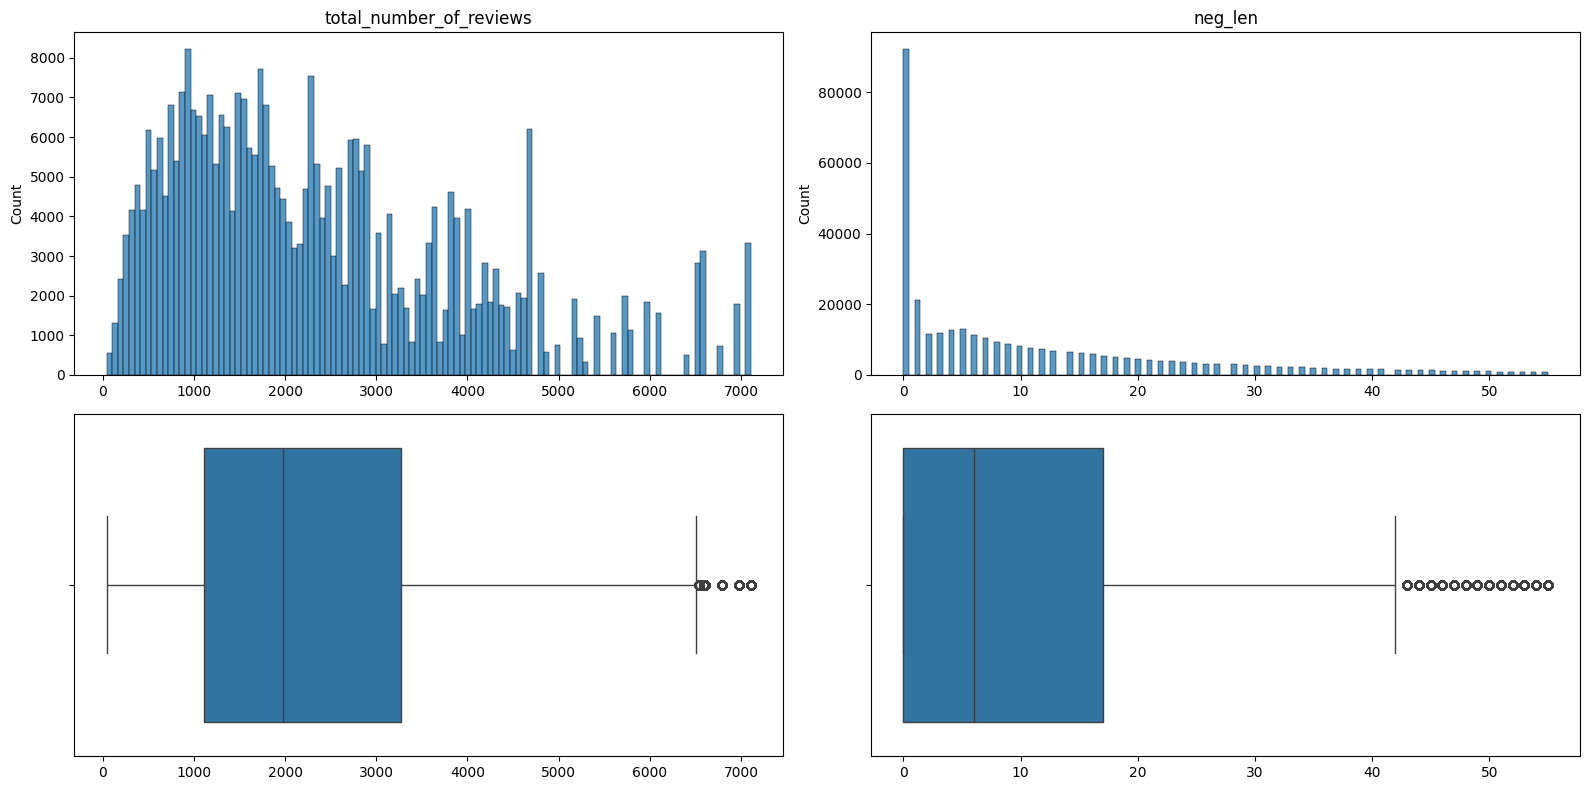

In [28]:
# Выведем диаграммы после удаления выбросов
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8))

for i, col in enumerate(columns):
    sns.histplot(data=hotels_clean, x=col, ax=axes[0, i])
    axes[0, i].set_title(f'{col}')
    axes[0, i].set_xlabel('')
    
    # Нижний ряд — boxplot
    sns.boxplot(data=hotels_clean, x=col, ax=axes[1, i])
    axes[1, i].set_xlabel('')

plt.tight_layout()
plt.show()

### Вывод:

После удаления выбросов распределения стали более компактными:
- Boxplot: усы стали короче, выбросов практически нет

Данные стали более пригодными для обучения модели.

In [29]:
# Выполним логарифмирование признаков
for col in columns:
    hotels_clean[f'log_{col.replace(" ", "_")}'] = np.log(hotels_clean[col] + 1)

### Вывод:

Применено логарифмирование к 2 признакам.

Логарифмирование сжимает длинный правый хвост, делая распределение более нормальным.

Это помогает модели лучше воспринимать признаки с большим разбросом значений.

In [30]:
# Проверяем результат
display(hotels_clean.head(2))
display(hotels_clean.info())

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,total_number_of_reviews,positive_review,total_number_of_reviews_reviewer_has_given,...,tag_Solo_traveler,tag_Business_trip,tag_Group,tag_Family_with_young_children,tag_Stayed_1_night,tag_Stayed_2_nights,tag_Stayed_3_nights,tag_Stayed_4_nights,log_total_number_of_reviews,log_neg_len
0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,Leaving,1994,Staff were amazing,7,...,0,0,0,0,0,1,0,0,7.598399,0.693147
1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,1361,location,14,...,0,1,0,0,1,0,0,0,7.216709,1.098612


<class 'pandas.DataFrame'>
Index: 341982 entries, 0 to 386802
Data columns (total 38 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               341982 non-null  str           
 1   additional_number_of_scoring                341982 non-null  int64         
 2   review_date                                 341982 non-null  datetime64[us]
 3   average_score                               341982 non-null  float64       
 4   hotel_name                                  341982 non-null  str           
 5   reviewer_nationality                        341982 non-null  str           
 6   negative_review                             341982 non-null  str           
 7   total_number_of_reviews                     341982 non-null  int64         
 8   positive_review                             341982 non-null  str           
 9   total_num

None

### Вывод:

Второй вариант значительно расширил набор признаков за счёт извлечения информации из даты, отзывов, тегов, адреса и страны рецензента. Это должно улучшить качество модели по сравнению с первым вариантом, где использовались только числовые признаки.

#### <center> 11. Построение модели

In [31]:
# Создаем независимую копию DataFrame
hotels_copy = hotels_clean.copy()

# Удаляем все строковые столбцы
object_columns = [s for s in hotels_copy.columns if hotels_copy[s].dtypes not in ['int64', 'float64']]
hotels_copy.drop(object_columns, axis=1, inplace=True)

# Разделяем на признаки (X) и целевую переменную (y)
X = hotels_copy.drop(['reviewer_score'], axis = 1)  
y = hotels_copy['reviewer_score']

In [ ]:
# Импортируем необходимые библиотеки
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Разбиваем на обучающую и тестовую выборки (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Отбираем лучшие признаки с помощью SelectKBest
selector = SelectKBest(score_func=f_regression)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [33]:
# Сохраняем и выводим значимость признаков
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'F-статистика': selector.scores_
}).sort_values('F-статистика', ascending=False)

# Выводим значимость всех признаков
print(feature_importance)

                                       Признак  F-статистика
28                                 log_neg_len  48380.952114
1                                average_score  37457.425974
6                                      neg_len  36855.349177
8                                      has_neg  29104.231285
9                                      has_pos  17921.611976
7                                      pos_len  15192.476783
17                            tag_Leisure_trip   3720.271405
20                           tag_Business_trip   3492.697073
19                           tag_Solo_traveler   1870.948532
5                             nationality_code   1487.235372
18                                  tag_Couple   1474.224632
27                 log_total_number_of_reviews   1283.313951
2                      total_number_of_reviews   1208.840005
0                 additional_number_of_scoring    364.394797
10                       hotel_country_Kingdom    349.290661
15                      

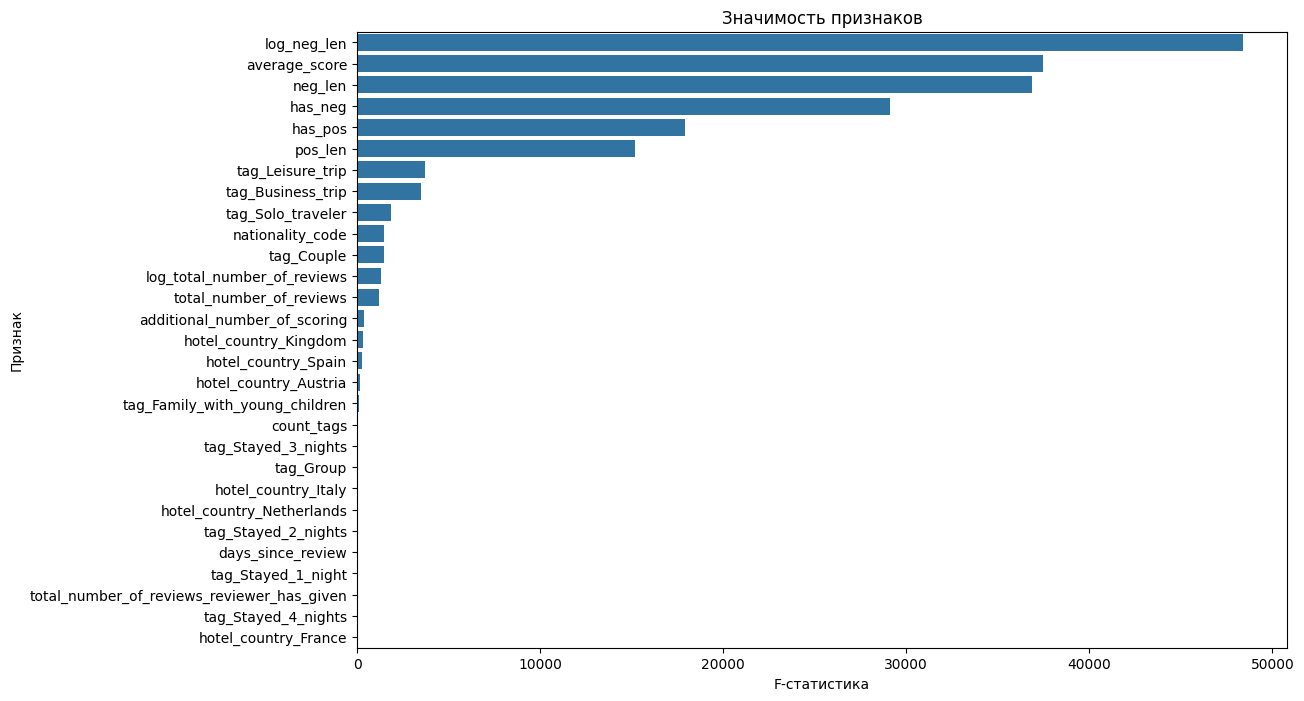

In [34]:
# Визуализируем все признаки
plt.figure(figsize=(12, 8))

# Сортируем и строим
top_features = feature_importance
sns.barplot(data=top_features, y='Признак', x='F-статистика')

# Задаем название диаграмме и осям
plt.title('Значимость признаков')
plt.xlabel('F-статистика')
plt.ylabel('Признак')

# Выводим диаграмму
plt.show()

### Вывод:

Построен список всех признаков с их F-статистикой (показатель важности для модели)

1. Выявлены самые сильные признаки:

    - neg_len (длина негативного отзыва),  average_score (средний балл отеля), has_neg (наличие негатива), has_pos (наличие позитива), pos_len (длина позитивного отзыва).

2. Выявлены слабые признаки (F < 10), которые почти не влияют на модель:

    - теги с количеством ночей, days_since_review, total_number_of_reviews_reviewer_has_given, hotel_country_France.

Для обучения модели оставляем 12 лучших признаков - это оптимальный баланс между качеством и скоростью.

In [35]:
# Отбираем 12 лучших признаков с помощью SelectKBest
selector = SelectKBest(score_func=f_regression, k=12)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [36]:
# Создаём и обучаем модель на отобранных признаках
regr = RandomForestRegressor(n_estimators=100)
regr.fit(X_train_selected, y_train)

# Предсказываем и оцениваем качество
y_pred = regr.predict(X_test_selected)
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13496839358305482


## Общий вывод:

Во втором варианте мы добавили новые признаки (длина отзывов, теги, страна, квартал), применили логарифмирование для скошенных признаков и удалили выбросы по IQR. 

Это позволило улучшить качество модели с MAPE = 14.35% до 13.49%

In [37]:
# Выгружаем DataFrame для работы в 3 варианте
hotels_clean.to_csv('hotels_clean.csv', index=False)

Для улучшения модели были протестированы внешние источники данных (погода, экономика, местные события). Однако в открытом доступе не найдено подходящих датасетов, покрывающих необходимый период (2015-2017) и географию (Великобритания, Испания, Франция, Нидерланды, Австрия, Италия). Поэтому в рамках данного проекта использованы только внутренние признаки с преобразованиями (логарифмирование, удаление выбросов).

В итоге улучшить модель удалось лишь на 0.86%